# Julián Serrano Chacón
# Mika Rodríguez Castro
  
# Práctica 2

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import sounddevice as sd
import time # para medir tiempos de ejecución
import soundfile as sf     
from ipywidgets import interact
from ipywidgets import fixed
import sys
import scipy.signal as sg
from tkinter import *

# graficos en el notebook
%matplotlib inline

SRATE = 48000 # Sample rate, para todo el notebook

CHUNK = 1024


class Osc:
    def __init__(self,freq=440.0,amp=1.0,phase=0.0,shape='sin', volume = 1):
        self.freq = freq
        self.amp = amp
        self.phase = phase
        self.frame = 0
        self.shape = shape
        self.volume = volume

    def next(self):    
        if self.shape=='sin':
            out = np.sin(2*np.pi*(np.arange(self.frame,self.frame+CHUNK))*self.freq/SRATE+self.phase)
        elif self.shape=='square':
            out = sg.square(2*np.pi*(np.arange(self.frame,self.frame+CHUNK))*self.freq/SRATE+self.phase)
        elif self.shape=='sawtooth':
            out = sg.sawtooth(2*np.pi*(np.arange(self.frame,self.frame+CHUNK))*self.freq/SRATE+self.phase)
        elif self.shape=='triangle':
            # Ojo, la triangular no existe como tal en scipy, pero podemos hacerla con dos sawtooth
            # el 2º parametro define la "rampa" la subida y bajada (ver documentacion)
            out = sg.sawtooth(2*np.pi*(np.arange(self.frame,self.frame+CHUNK))*self.freq/SRATE+self.phase,0.5)
        self.frame += CHUNK

        return np.float32(self.amp*out * self.volume)
    
    def getVol(self):
        return self.volume
    
    def getFreq(self):
        return self.freq
    
    def getAmp(self):
        return self.amp
    
    def setVol(self, volume):
        if volume > 1:
            self.volume = 1
        elif volume < 0:
            self.volume = 0
        else:
            self.volume = volume

    def setFreq(self, freq):
        self.freq = freq

    def setAmp(self, amp):
        if amp > 1:
            self.amp = 1
        elif amp < 0:
            self.amp = 0
        else:
            self.amp = amp


In [ ]:
%%writefile consts.py

# mapeo de teclas del ordenador a notas en el piano
# utilizamos '.' para los sostenidos
teclas = "zsxdcvgbhnjmq2w3er5t6y7u"  # 2 de teclas filas 
notas =  "C.D.EF.G.A.Bc.d.ef.g.a.b"  # mapeadas a 2 octavas
#         octava baja||octava alta


# frecuencias de las notas asociadas a las teclas del teclado
# partimos del la=220Hz y generamos frecuencias de escala temperada
pitchs = [ 220*2.0**(i/12.0) for i in range(len(teclas))] 

# frecuencias asociadas a las notas midi de 0 a 127
# El LA central es la nota midi 70 y su frecuencia es 440
# construimos hacia abajo y hacia arriba el resto de notas
freqsMidi = [ 440*2.0**(i/12.0) for i in range(-69,59)]

#### Ejercicio 1   
(Evaluable) Implementar una clase AMmodulator para modular en amplitud (volumen) una
señal dada signal. La constructora seá de la forma:  
__init__(self,signal,shape=’sin’,freq=1,v0=0,v1=1)  
donde signal es la señal a modular (un objeto generador de señal, i.e., que implementa el método
next) y el resto de parámetros se refieren al modulador:  
• shape: forma de onda del modulador (puede ser sin, saw, square o triangle)  
• freq: la frecuencia del modulador (en Hz)  
• v0,v1: los valores mínimo y máximo de la onda moduladora (en el rango [0,1], donde 0 es
silencio y 1 es el volumen máximo de la señal original). ¿Qué ocurriría si dejamos que v0,v1
estén fuera de ese rango?  
La clase AMmodulator, será a su vez un generador de señal, es decir implementará el método next
para devolver la señal signal modulada. De este modo, podremos por ejemplo moudular una señal
triangular de 440 Hz con un modulador de 2 Hz y amplitud de 0.2 a 0.9:  
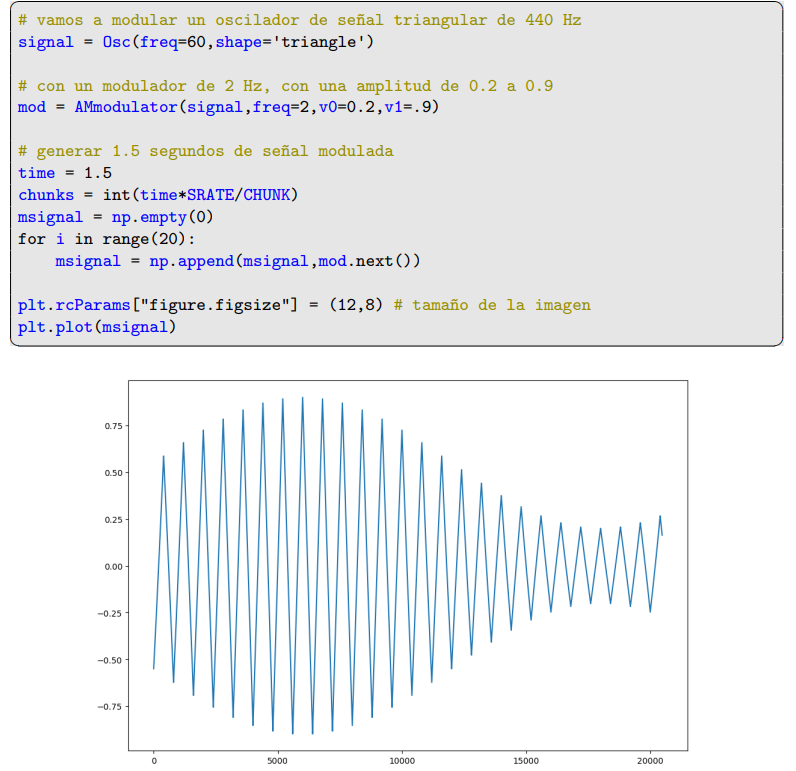

In [ ]:
signal = Osc(60,shape='triangle')

class AMmodulator:
    def __init__(self, signal, shape = 'sin', freq = 1, v0 = 0, v1 = 1):
        self.signal = signal
        self.shape = shape
        self.freq = freq
        self.v0 = v0
        self.v1 = v1
        self.osc = Osc(freq, shape=shape)

    def next(self):
         mod = self.osc.next()
         mod = mod * (self.v1-self.v0)/2 + (self.v0+(self.v1-self.v0)/2)
         return np.float32(self.signal.next() * mod)
        
modulator = AMmodulator(signal,freq=2,v0=0.2,v1=0.9)

time = 1.5
chunks = int(time*SRATE/CHUNK)
mSignal = np.empty(0)
for i in range(chunks):
    mSignal = np.append(mSignal, modulator.next())

plt.rcParams["figure.figsize"] = (12,8)
plt.plot(mSignal)
sd.play(mSignal)



#### Ejercicio 2  
Extender la clase Osc vista en clase con los métodos get/set para poder obtener y modificar dinámicamente el volumen y la frecuencia del oscilador.  
Después, utilizar la librería TkInter para capturar pulsación de teclas e implementar una interfaz para controlar el oscilador anterior en tiempo real:  
permitirá subir/bajar la frecuencia con las teclas [f/F] y el volumen con [v/V].


In [ ]:
signal = Osc(440,shape='triangle')

time = 20
#chunks = int(time*SRATE/CHUNK)
#mSignal = np.empty(0)
#for i in range(chunks):
    #mSignal = np.append(mSignal,signal.next())


# stream de salida con callBack


def callback(outdata, frames, time, status):
    if status: print(status)
    # si hay generador de señal conectado, pedimos el siguiente bloque
    if signal:    
        s = signal.next()
        s = np.float32(s)
    # si no, generamos silencio    
    else:
        s = np.zeros(CHUNK,dtype=np.float32)
    outdata[:] = s.reshape(-1, 1)

# stream de salida con callBack
stream = sd.OutputStream(samplerate=SRATE, callback=callback, blocksize=CHUNK)
stream.start()



# inicialización de la ventanas 
root=Tk()

# Caja de texto
text = Text(root,height=6,width=60)
text.pack(side=BOTTOM)
text.insert(INSERT,"Press 'f/F' to change freq, 'v/V'space' to to change volume and s to stop the signal\n")

volMod = 0.02
freqMod = 20

#sd.play(mSignal)
# call back para la pulsación de teclas
def key_down(event):
    if event.char=='v': 
        signal.setVol(signal.getVol() - volMod)
    if event.char=='V': 
        signal.setVol(signal.getVol() + volMod)
    if event.char=='f': 
        signal.setFreq(signal.getFreq() - freqMod)
    if event.char=='F': 
        signal.setFreq(signal.getFreq() + freqMod)
    elif event.char== 's' or  event.char== 'S':         
        stream.stop()
        stream.close()

# enlace de la pulsación de teclas con la función key_down
text.bind('<Key>', key_down)

# arrancamos todo!!
root.mainloop()
# ejecución bloqueada hasta que se cierre ventana


# limpieza..
stream.stop()
stream.close()

#### Ejercicio 3
Implementar una clase MultiOsc que permita mezclar señal de los 4 osciladores básicos que hemos
visto (sin, saw, square o triangle).  
La constructora recibirá la frecuencia (será la misma para todos los osciladores) y una lista con los coeficientes de mezcla de cada oscilador (en el mismo orden
que el listado anterior).  
Utilizando TkInter o los widgets de IPython, implementar un interfaz para controlar dinámicamente los coeficientes de mezcla de cada oscilador (con un rango de valores entre 0 y 1).  
Probarlo con distintas combinaciones de osciladores y coeficientes para obtener timbres interesantes.

In [2]:
class MultiOsc:
    def __init__(self,freq = 440,amp=1.0,phase=0.0, coefs = [1,1,1,1]):
        self.freq = freq
        self.coefs = coefs 
        self.sin = Osc(freq,amp,phase,'sin',coefs[0])
        self.saw = Osc(freq,amp,phase,'sawtooth',coefs[1])
        self.square = Osc(freq,amp,phase,'square',coefs[2])
        self.triangle = Osc(freq,amp,phase,'triangle',coefs[3])

    def next(self):
        return np.float32(((self.sin.next()* self.coefs[0]) +
        (self.saw.next() * self.coefs[1]) +
        (self.square.next() * self.coefs[2]) +
        (self.triangle.next() * self.coefs[3])))
    
    def SetCoef(self,index, param):
        self.coefs[index]=param
    

signal = MultiOsc(220)

def callback(outdata, frames, time, status):
    if status: print(status)
    # si hay generador de señal conectado, pedimos el siguiente bloque
    if signal:    
        s = signal.next()
        s = np.float32(s)
    # si no, generamos silencio    
    else:
        s = np.zeros(CHUNK,dtype=np.float32)

    outdata[:] = s.reshape(-1, 1)

# stream de salida con callBack
stream = sd.OutputStream(samplerate=SRATE, callback=callback, blocksize=CHUNK)
stream.start()


def sinCoefCtrl(sinCoef):
    global signal
    signal.SetCoef(0,sinCoef)
interact(sinCoefCtrl, sinCoef=(0.0,1.0,0.01))

def sawCoefCtrl(sawCoef):
    global signal
    signal.SetCoef(1,sawCoef)
interact(sawCoefCtrl, sawCoef=(0.0,1.0,0.01))

def squareCoefCtrl(squareCoef):
    global signal
    signal.SetCoef(2,squareCoef) 
interact(squareCoefCtrl, squareCoef=(0.0,1.0,0.01))

def triangleCoefCtrl(triangleCoef):
    global signal
    signal.SetCoef(3,triangleCoef) 
interact(triangleCoefCtrl, triangleCoef=(0.0,1.0,0.01))


def pauseCtrl(pause):
    if pause==True:
        stream.stop()        
    else:
        stream.start()   
# lo interpreta como un checkbox
interact(pauseCtrl, pause=False)       



def stopCtrl(stop):
    if stop==True:
        stream.stop()
        stream.close()
interact(stopCtrl, stop=False)      



interactive(children=(FloatSlider(value=0.5, description='sinCoef', max=1.0, step=0.01), Output()), _dom_class…

interactive(children=(FloatSlider(value=0.5, description='sawCoef', max=1.0, step=0.01), Output()), _dom_class…

interactive(children=(FloatSlider(value=0.5, description='squareCoef', max=1.0, step=0.01), Output()), _dom_cl…

interactive(children=(FloatSlider(value=0.5, description='triangleCoef', max=1.0, step=0.01), Output()), _dom_…

interactive(children=(Checkbox(value=False, description='pause'), Output()), _dom_classes=('widget-interact',)…

interactive(children=(Checkbox(value=False, description='stop'), Output()), _dom_classes=('widget-interact',))

<function __main__.stopCtrl(stop)>

#### Ejercicio 4  
En este ejercicio vamos a implementar un efecto de modulación de paneo (o balance de canales)
para muestras estéreo.  
En primer lugar, si tenemos un array numpy con una señal estéreo, podemos obtener los canales con left, right = bloque[:,0], bloque[:,1]. Una vez realizadas
las operaciones deseadas con cada canal, podemos recomponer la muestra estéreo con bloque = np.column_stack((left,right))  
El paneo es la cantidad de señal que se manda a cada canal. Hay distintas alternativas de implementación (consultar capítulo 9 de Hack Audio: An Introduction to Computer Programming and Digital Signal Processing in MATLAB. Eric Tarr. Routledge, 2019.)  
Una forma razonable para conseguir equal power panning es utilizar la fórmula square-law panning.
En este caso, dado un valor de paneo p ∈ [0, 1], la amplitud de cada canal viene dada por:  
  
  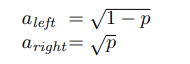    
   
De este modo, con p = 0 irá toda la señal al canal izquierdo (nada al derecho), con p = 1 irá toda la
señal al derecho y con p = 0.5 irá la misma señal a uno y otro. En nuestro caso, queremos modular
ese coeficiente (que varíe con el tiempo).  
Para conseguirlo puede utilizarse la clase Modulator del
ejercicio anterior o implementar ad-hoc dicho modulador.


In [ ]:
paneo = 0

signal, SRATE = sf.read('media/ex1.wav',dtype=np.float32)

current_frame = 0
def callback(outdata, frames, time, status):
    global current_frame       # para actualizarlo en cada callBack
    if status: print(status)

    # ojo, este print es muy lento... puede provocar underruns
    #print(f"\rNum Bloque: {current_frame//CHUNK}  frame: {current_frame}", end='') 

    # escribimos los samples correspondientes en el outdata que viene dado
    bloque = signal[current_frame : current_frame+CHUNK]
        
    left = bloque[:,0]
    right = bloque[:,1]
    left *= np.sqrt(1-paneo)
    right *= np.sqrt(paneo)
    bloque = np.column_stack((left, right))

    chunksize = bloque.shape[0]

    outdata[:chunksize] = bloque       
    
    if chunksize < frames: # ha terminado?
        print('fin')
        outdata[chunksize:] = 0 # rellenamos con 0's el resto de outdata
        raise sd.CallbackStop()

    # actualizamos frame con los frames procesados    
    current_frame += chunksize



# stream de salida con callBack
stream = sd.OutputStream(samplerate=SRATE, callback=callback, blocksize=CHUNK, channels=len(signal.shape))
stream.start()

def paneoCtrl(pan):
    global paneo
    paneo = pan
interact(paneoCtrl, pan=(0.0,1.0,0.01))


def pauseCtrl(pause):
    if pause==True:
        stream.stop()        
    else:
        stream.start()   
# lo interpreta como un checkbox
interact(pauseCtrl, pause=False)       



def stopCtrl(stop):
    if stop==True:
        stream.stop()
        stream.close()
interact(stopCtrl, stop=False)  

#### Ejercicio 5
 En este ejercicio implementaremos una clase SumOsc que, dada una frecuencia f y una lista de coeficientes coefs=[c0,c1,...,cn] genera la mezcla de señal de los osciladores Osc con frecuencias
[f,2f,3f,...,nf] con amplitudes coefs. Utilizando TkInter o los widgets de IPython, implementar un interfaz para controlar dinámicamente los coeficientes de mezcla de cada oscilador (con un
rango de valores entre 0 y 1). Probarlo con estas combinaciones de coeficientes:  
• [1,0.5,0.3,0.6,0.2,0.1,0.2,0.1,0.05,0.3,0.2,0.15]  
• [1,0,0.4,0,0.2,0,0.1,0,0.05,0.1,0,0.15]  
• [0.5,0,0.37,0.04,0,0.1,0,0.012]  
Probarlo con otras combinaciones de osciladores y coeficientes para obtener timbres interesantes.

In [4]:
class SumOsc:
    def __init__(self,freq = 440,amp=1.0,phase=0.0, coefs = [1,1,1,1]):
        self.freq = freq
        self.coefs = coefs 
        self.phase = phase
        self.oscs = np.empty(dtype=Osc, shape=len(coefs))

        i = 0
        for coef in coefs:
            self.oscs[i] = Osc(freq)
            i += 1

    def next(self):
        data = np.zeros(CHUNK)
        for osc in self.oscs:
            data += osc.next()
        
        return data
    
    def SetCoef(self,index, param):
        self.coefs[index]=param
        self.oscs[index].setAmp(param)
    
    def getNumOscs(self):
        return len(self.oscs)

signal = SumOsc(220)

def callback(outdata, frames, time, status):
    if status: print(status)
    # si hay generador de señal conectado, pedimos el siguiente bloque
    if signal:
        s = signal.next()
        s = np.float32(s)
    # si no, generamos silencio    
    else:
        s = np.zeros(CHUNK,dtype=np.float32)

    outdata[:] = s.reshape(-1, 1)

# stream de salida con callBack
stream = sd.OutputStream(samplerate=SRATE, callback=callback, blocksize=CHUNK)
stream.start()

def coefCtrl(coef, index):
    global signal
    signal.SetCoef(index, coef)

for i in range(0, signal.getNumOscs()):
    interact(coefCtrl, coef=(0.0,1.0,0.01), index=fixed(i))

def pauseCtrl(pause):
    if pause==True:
        stream.stop()        
    else:
        stream.start()   
# lo interpreta como un checkbox
interact(pauseCtrl, pause=False)       


def stopCtrl(stop):
    if stop==True:
        stream.stop()
        stream.close()
interact(stopCtrl, stop=False) 

interactive(children=(FloatSlider(value=0.5, description='coef', max=1.0, step=0.01), Output()), _dom_classes=…

interactive(children=(FloatSlider(value=0.5, description='coef', max=1.0, step=0.01), Output()), _dom_classes=…

interactive(children=(FloatSlider(value=0.5, description='coef', max=1.0, step=0.01), Output()), _dom_classes=…

interactive(children=(FloatSlider(value=0.5, description='coef', max=1.0, step=0.01), Output()), _dom_classes=…

interactive(children=(Checkbox(value=False, description='pause'), Output()), _dom_classes=('widget-interact',)…

interactive(children=(Checkbox(value=False, description='stop'), Output()), _dom_classes=('widget-interact',))

<function __main__.stopCtrl(stop)>